In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Streaming output truncated to the last 5000 lines.
|    time_elapsed    | 1694     |
|    total_timesteps | 62550    |
| train/             |          |
|    actor_loss      | 63.6     |
|    critic_loss     | 13.7     |
|    learning_rate   | 0.001    |
|    n_updates       | 62449    |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 344      |
|    fps             | 36       |
|    time_elapsed    | 1718     |
|    total_timesteps | 63325    |
| train/             |          |
|    actor_loss      | 65.8     |
|    critic_loss     | 22.4     |
|    learning_rate   | 0.001    |
|    n_updates       | 63224    |
---------------------------------
---------------------------------
| time/              |          |
|    episodes        | 348      |
|    fps             | 36       |
|    time_elapsed    | 1732     |
|    total_timesteps | 63814    |
| train/             |          |
|    actor_loss      | 66.2    

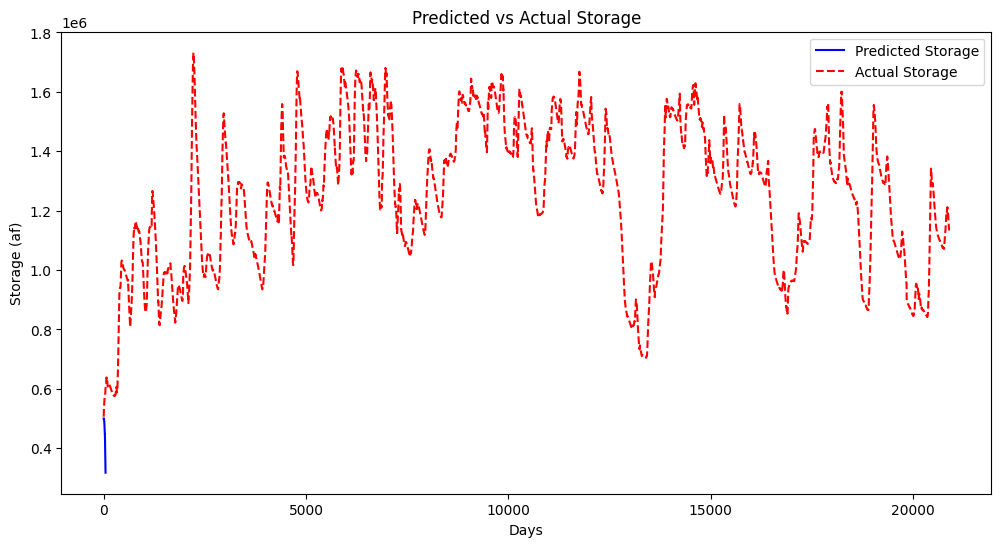

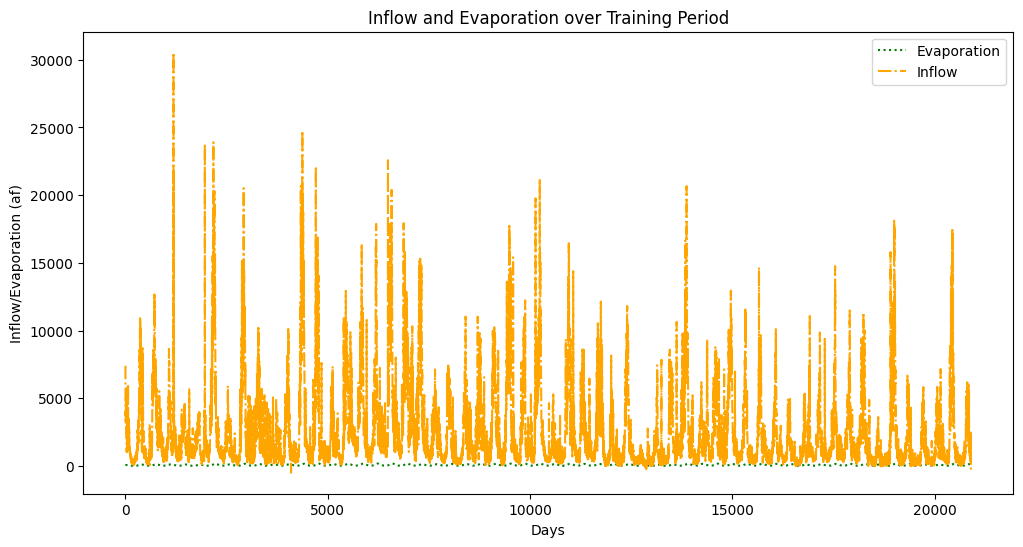

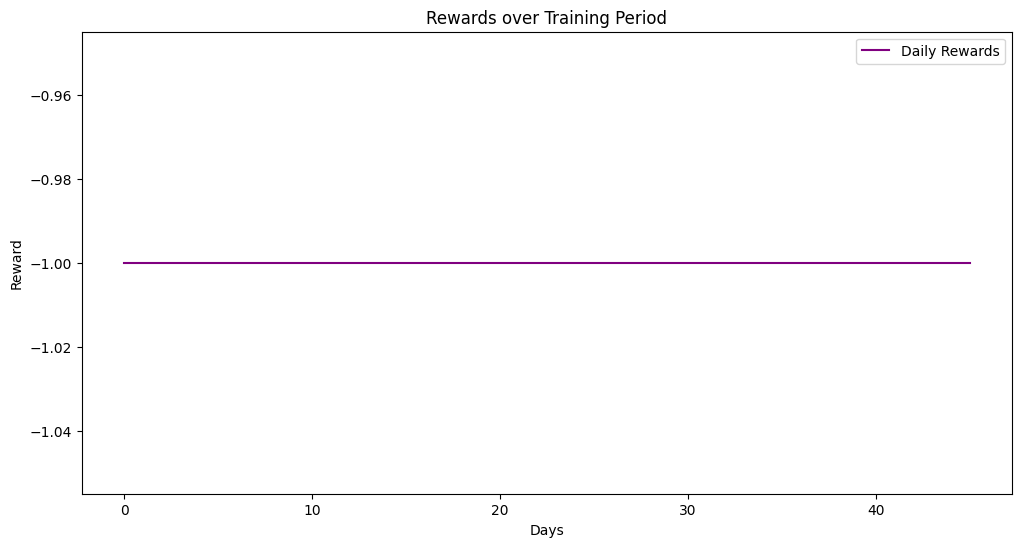

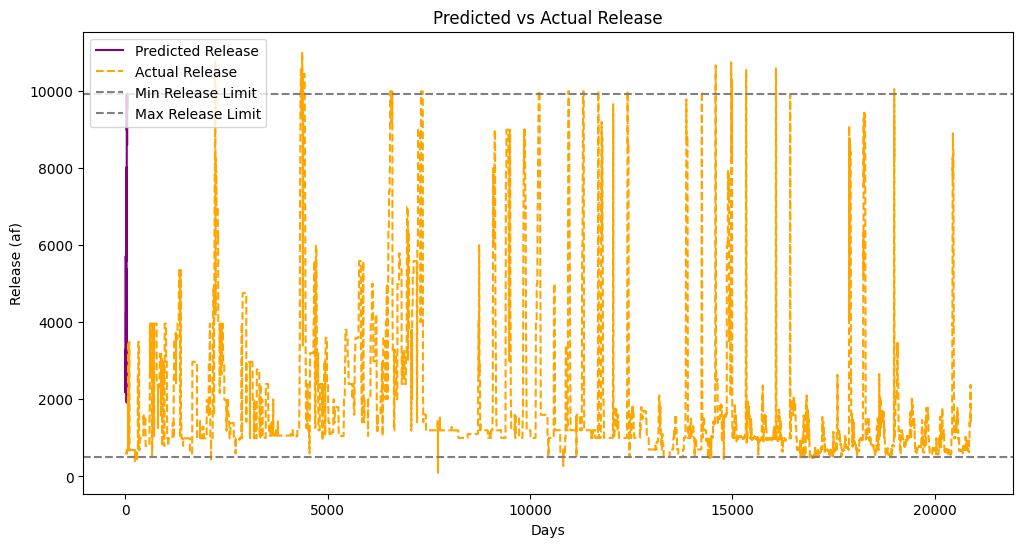

In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1600000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
navajo_min_release = 250 * 1.98211
navajo_max_release = 5000 * 1.98211

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, data, scaler, episode_length=365):
        super(ReservoirEnv, self).__init__()
        self.data = data
        self.scaler = scaler
        self.episode_length = episode_length
        self.current_step = 0
        self.storage_history = []
        self.predicted_release_history = []
        self.reward_history = []
        self.q_values = []

        # Unscaled data for actual values
        unscaled_data = self.scaler.inverse_transform(self.data)
        self.actual_storage_history = unscaled_data[:, 0].tolist()
        self.actual_release_history = unscaled_data[:, 3].tolist()
        self.evaporation_history = unscaled_data[:, 1].tolist()
        self.inflow_history = unscaled_data[:, 2].tolist()

        self.action_space = Box(low=0, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=0, high=1, shape=(3,), dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.storage_history.clear()
        self.predicted_release_history.clear()
        self.reward_history.clear()
        self.q_values.clear()
        self.current_storage = initial_storage_af  # Reset to initial realistic storage
        self.storage_history.append(self.current_storage)
        return self._get_observation(), {}

    def _get_observation(self):
        return self.data[self.current_step, :3]

    def step(self, action):
        release_scaled = action[0]
        release_af = np.clip(
            release_scaled * (navajo_max_release - navajo_min_release) + navajo_min_release,
            navajo_min_release,
            navajo_max_release,
        )
        self.predicted_release_history.append(release_af)
        inflow_af = self.scaler.inverse_transform(self.data[self.current_step:self.current_step + 1, :])[0, 2]
        evaporation_af = self.scaler.inverse_transform(self.data[self.current_step:self.current_step + 1, :])[0, 1]

        self.current_storage += inflow_af - evaporation_af - release_af
        self.storage_history.append(self.current_storage)

        # Modified binary reward: reward based on how close the current storage is to target
        if abs(self.current_storage - target_storage_af) < (max_storage_af - min_storage_af) * 0.05:
            reward = 1  # Positive reward if storage is close to target
        else:
            reward = -1  # Small negative reward for deviation

        self.reward_history.append(reward)

        self.current_step += 1
        done = self.current_step >= len(self.data) or (self.current_step % self.episode_length == 0)
        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

    def render(self, mode='human', close=False):
        pass


# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Set up environment
episode_length = 365
env = ReservoirEnv(scaled_data, scaler, episode_length=episode_length)
env = DummyVecEnv([lambda: env])

# Set up TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3(
    "MlpPolicy",
    env,
    action_noise=action_noise,
    learning_rate=0.001,
    batch_size=128,
    tau=0.005,
    gamma=0.99,
    verbose=1,
)

# Train the model
n_episodes = 1000
total_timesteps = n_episodes * episode_length
model.learn(total_timesteps=total_timesteps)

# Save and reload model
model.save("td3_reservoir_agent")
model = TD3.load("td3_reservoir_agent")

# Generate and save plots and data
plt.figure(figsize=(12, 6))
plt.plot(env.envs[0].storage_history, label="Predicted Storage", color='blue')
plt.plot(env.envs[0].actual_storage_history, label="Actual Storage", color='red', linestyle='--') # Slice actual_storage_history to match length
plt.xlabel('Days')
plt.ylabel('Storage (af)')
plt.title('Predicted vs Actual Storage')
plt.legend()
plt.show()
# Save storage data
pd.DataFrame({
    "Predicted Storage": env.envs[0].storage_history[:-1],
    "Actual Storage": env.envs[0].actual_storage_history[:len(env.envs[0].storage_history[:-1])]
}).to_csv("predicted_vs_actual_storage.csv", index=False)

plt.figure(figsize=(12, 6))
plt.plot(env.envs[0].evaporation_history, label="Evaporation", color='green', linestyle=':')
plt.plot(env.envs[0].inflow_history, label="Inflow", color='orange', linestyle='-.')
plt.xlabel('Days')
plt.ylabel('Inflow/Evaporation (af)')
plt.title('Inflow and Evaporation over Training Period')
plt.legend()
plt.show()
# Save inflow and evaporation data
pd.DataFrame({
    "Evaporation": env.envs[0].evaporation_history,
    "Inflow": env.envs[0].inflow_history
}).to_csv("inflow_evaporation.csv", index=False)

plt.figure(figsize=(12, 6))
plt.plot(env.envs[0].reward_history, label="Daily Rewards", color='purple')
plt.xlabel('Days')
plt.ylabel('Reward')
plt.title('Rewards over Training Period')
plt.legend()
plt.show()
# Save reward data
pd.DataFrame({
    "Reward": env.envs[0].reward_history
}).to_csv("reward_history.csv", index=False)


plt.figure(figsize=(12, 6))
plt.plot(env.envs[0].predicted_release_history, label="Predicted Release", color='purple')
plt.plot(env.envs[0].actual_release_history, label="Actual Release", color='orange', linestyle='--')
plt.axhline(y=navajo_min_release, color='gray', linestyle='--', label="Min Release Limit")
plt.axhline(y=navajo_max_release, color='gray', linestyle='--', label="Max Release Limit")
plt.xlabel('Days')
plt.ylabel('Release (af)')
plt.title('Predicted vs Actual Release')
plt.legend()
plt.show()
# Save release data
pd.DataFrame({
    "Predicted Release": env.envs[0].predicted_release_history,
    "Actual Release": env.envs[0].actual_release_history[:len(env.envs[0].predicted_release_history)]
}).to_csv("predicted_vs_actual_release.csv", index=False)

In [3]:
import pandas as pd
import numpy as np
import torch as th
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import TD3
from gymnasium.spaces import Box

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1900000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
navajo_min_release = 250 * 1.98211
navajo_max_release = 5000 * 1.98211

# Load the data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(dataset)

# Load the trained TD3 agent
model = TD3.load("td3_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

current_storage = initial_storage_af

# Perform predictions
for i in range(len(scaled_data)):
    observation = scaled_data[i, :3]
    action, _ = model.predict(observation, deterministic=True)
    release_scaled = action[0]
    predicted_release_af = np.clip(
        release_scaled * (navajo_max_release - navajo_min_release) + navajo_min_release,
        navajo_min_release,
        navajo_max_release,
    )

    # Calculate predicted storage
    inflow_af = scaler.inverse_transform([scaled_data[i]])[0, 2]
    evaporation_af = scaler.inverse_transform([scaled_data[i]])[0, 1]
    current_storage += inflow_af - evaporation_af - predicted_release_af

    # Store results
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])
    actual_release.append(dataset[i, 3])

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

# Save to CSV
predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved to CSV files.")

Prediction completed and saved to CSV files.


   Predicted Storage (af)  Actual Storage (af)
0           501594.011057             506159.0
1           501724.224935             511433.0
2           501328.179662             516180.0
3           500580.300920             520575.0
4           499799.025098             523622.0


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


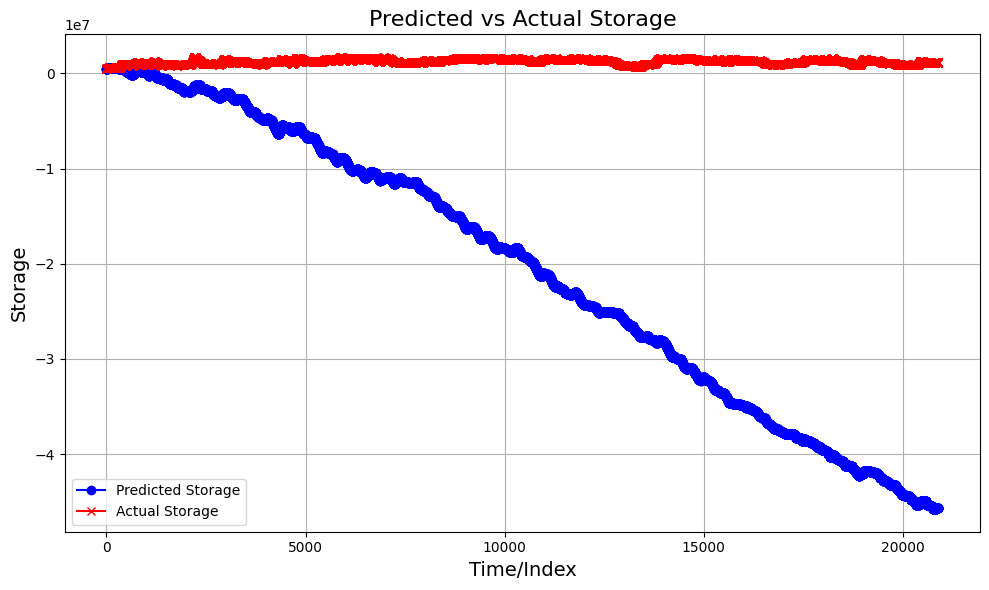

In [4]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the correct CSV file for predicted vs actual storage
df = pd.read_csv('/content/predicted_vs_actual_storage_complete_data.csv')

# Check the first few rows of the data to understand its structure
print(df.head())

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(df['Predicted Storage (af)'], label='Predicted Storage', color='blue', marker='o')
plt.plot(df['Actual Storage (af)'], label='Actual Storage', color='red', marker='x')

# Adding titles and labels
plt.title('Predicted vs Actual Storage', fontsize=16)
plt.xlabel('Time/Index', fontsize=14)
plt.ylabel('Storage', fontsize=14)
plt.legend()

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()